# Image2GPS Baseline Data and Dataloaders

This notebook loads our train/validation data from the Hugging Face Dataset repo and sets up the baseline-style PyTorch dataset and dataloaders.

If the Hugging Face dataset is private, run `hf auth login` in a terminal first and set `USE_AUTH_TOKEN = True` below. If the dataset is public, the default settings should work without login.

We are not using a local test split for now because the dataset is small and the professor leaderboard/test set is the true held-out test. The notebook follows the example `Release_baseline_model.ipynb` style by creating a custom dataset class and dataloaders before model code.


In [1]:
# Uncomment and run this cell if your kernel is missing dependencies.
%pip install datasets huggingface_hub torch torchvision numpy pillow matplotlib


# Data

## Loading the Train and Validation Datasets

Here we now load our uploaded Hugging Face Dataset directly instead of reading from the local `data/image2gps_dataset/` folder.


In [2]:
HF_DATASET_REPO_ID = "mhedlund/CIS5190IMG2GPS"
print("Dataset repo:", HF_DATASET_REPO_ID)


Dataset repo: mhedlund/CIS5190IMG2GPS


In [3]:
from datasets import load_dataset, Image

dataset_train = load_dataset(HF_DATASET_REPO_ID, split="train")
dataset_validation = load_dataset(HF_DATASET_REPO_ID, split="validation")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/479 [00:00<?, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/507M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/504M [00:00<?, ?B/s]

...

data/validation-00000-of-00003.parquet:   0%|          | 0.00/392M [00:00<?, ?B/s]

data/validation-00001-of-00003.parquet:   0%|          | 0.00/360M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1416 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/251 [00:00<?, ? examples/s]

In [4]:
print(dataset_train)
print(dataset_validation)


Dataset({
    features: ['image', 'Latitude', 'Longitude'],
    num_rows: 1416
})
Dataset({
    features: ['image', 'Latitude', 'Longitude'],
    num_rows: 251
})


In [5]:
dataset_train[0]

{'image': <PIL.Image.Image image mode=RGB size=3024x4032>,
 'Latitude': 39.95163055555556,
 'Longitude': -75.19216944444445}

## Defining the Custom Dataset Class

This is the same `GPSImageDataset` pattern from the baseline notebook.

In [6]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np


class GPSImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, lat_mean=None, lat_std=None, lon_mean=None, lon_std=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

        # Compute mean and std from the dataframe if not provided
        self.latitude_mean = lat_mean if lat_mean is not None else np.mean(np.array(self.hf_dataset['Latitude']))
        self.latitude_std = lat_std if lat_std is not None else np.std(np.array(self.hf_dataset['Latitude']))
        self.longitude_mean = lon_mean if lon_mean is not None else np.mean(np.array(self.hf_dataset['Longitude']))
        self.longitude_std = lon_std if lon_std is not None else np.std(np.array(self.hf_dataset['Longitude']))

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # Extract data
        example = self.hf_dataset[idx]

        # Load and process the image
        image = example['image'].convert('RGB')
        latitude = example['Latitude']
        longitude = example['Longitude']
        # image = image.rotate(-90, expand=True)
        if self.transform:
            image = self.transform(image)

        # Normalize GPS coordinates
        latitude = (latitude - self.latitude_mean) / self.latitude_std
        longitude = (longitude - self.longitude_mean) / self.longitude_std
        gps_coords = torch.tensor([latitude, longitude], dtype=torch.float32)

        return image, gps_coords

In [7]:
from torchvision.transforms import InterpolationMode

In [8]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),  # Random crop and resize to 224x224
    transforms.RandomHorizontalFlip(),  # Random horizontal flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Random color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Optionally, you can create a separate transform for inference without augmentations
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [9]:
# Create the training dataset and dataloader
train_dataset = GPSImageDataset(hf_dataset=dataset_train, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Retrieve normalization parameters from the training dataset
lat_mean = train_dataset.latitude_mean
lat_std = train_dataset.latitude_std
lon_mean = train_dataset.longitude_mean
lon_std = train_dataset.longitude_std

print("lat_mean:", lat_mean)
print("lat_std:", lat_std)
print("lon_mean:", lon_mean)
print("lon_std:", lon_std)

lat_mean: 39.95165652367781
lat_std: 0.0006337854727539858
lon_mean: -75.1915309442679
lon_std: 0.0006097230547761085


In [10]:
# Create the validation dataset and dataloader using training mean and std
val_dataset = GPSImageDataset(
    hf_dataset=dataset_validation,
    transform=inference_transform,
    lat_mean=lat_mean,
    lat_std=lat_std,
    lon_mean=lon_mean,
    lon_std=lon_std
)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


## Batch Shape Check

Confirms the image tensors and normalized GPS labels are the expected format.

In [11]:
images, gps_coords = next(iter(train_dataloader))

print("image batch shape:", images.shape)
print("gps batch shape:", gps_coords.shape)
print("first normalized gps label:", gps_coords[0])

image batch shape: torch.Size([32, 3, 224, 224])
gps batch shape: torch.Size([32, 2])
first normalized gps label: tensor([-0.1505, -0.6827])


In [12]:
# Convert normalized labels back to raw latitude/longitude for inspection.
gps_coords_denorm = gps_coords * torch.tensor([lat_std, lon_std]) + torch.tensor([lat_mean, lon_mean])
gps_coords_denorm[:5]

tensor([[ 39.9516, -75.1919],
        [ 39.9515, -75.1905],
        [ 39.9526, -75.1908],
        [ 39.9515, -75.1904],
        [ 39.9517, -75.1904]], dtype=torch.float64)

## Visualize Data

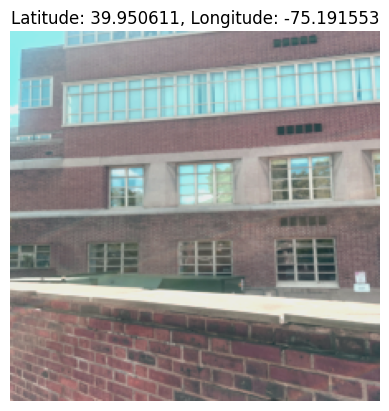

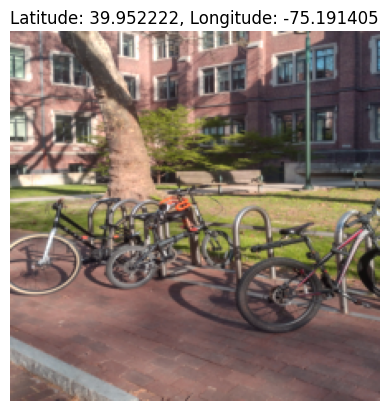

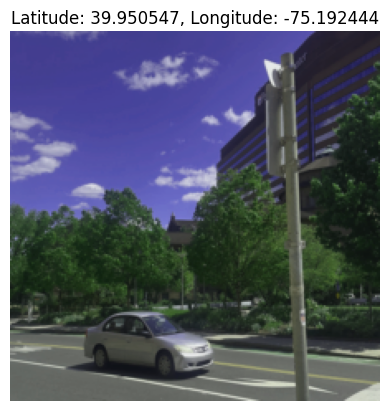

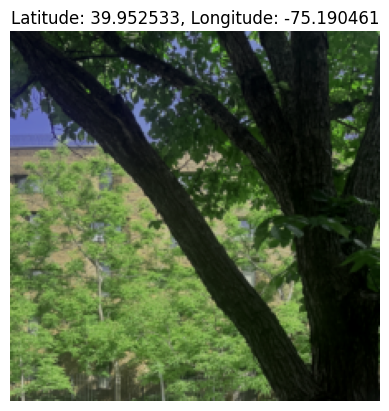

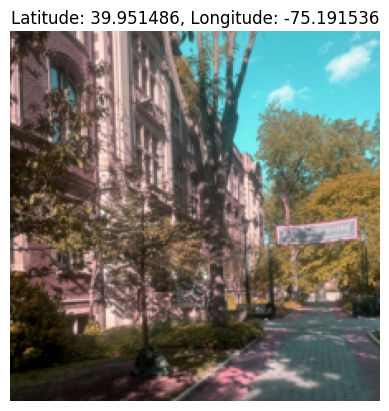

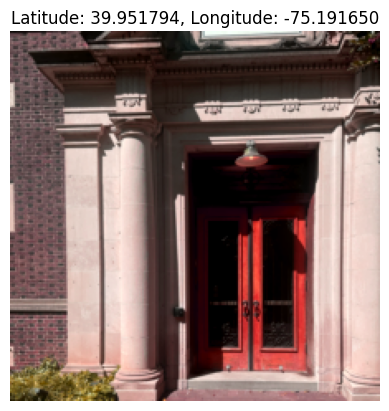

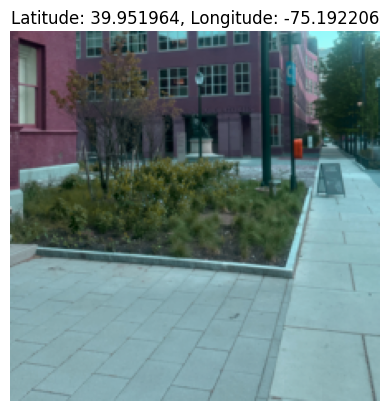

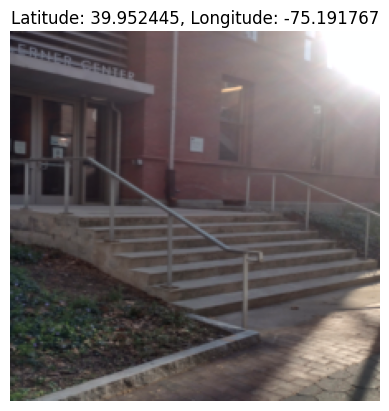

In [13]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np


def denormalize(tensor, mean, std):
    mean = np.array(mean)
    std = np.array(std)
    tensor = tensor.numpy().transpose((1, 2, 0))  # Convert from C x H x W to H x W x C
    tensor = std * tensor + mean
    tensor = np.clip(tensor, 0, 1)
    return tensor


data_iter = iter(train_dataloader)
images, gps_coords = next(data_iter)
gps_coords_real = gps_coords * torch.tensor([lat_std, lon_std]) + torch.tensor([lat_mean, lon_mean])

num_examples = min(8, len(images))
for i in range(num_examples):
    image = denormalize(images[i], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    plt.imshow(image)
    plt.title(
        f"Latitude: {gps_coords_real[i, 0].item():.6f}, "
        f"Longitude: {gps_coords_real[i, 1].item():.6f}"
    )
    plt.axis("off")
    plt.show()


## Next Step

At this point, `train_dataloader` and `val_dataloader` are ready to use for actual model code. Feel free to adjust the transforms or other parts of the pipeline if you think it will make the models behave better in the end!


## Model Architecture

We use ResNet18 as a regression model with 2 outputs.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [15]:
class ResNet18LocationRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        in_features = self.model.fc.in_features

        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)   # output: normalized [latitude, longitude]
        )

        self.register_buffer("lat_mean", torch.tensor(0.0))
        self.register_buffer("lat_std", torch.tensor(1.0))
        self.register_buffer("lon_mean", torch.tensor(0.0))
        self.register_buffer("lon_std", torch.tensor(1.0))

    def forward(self, x):
        return self.model(x)

In [16]:
# use average haversine distance for loss

class HaversineLoss(nn.Module):
    def __init__(self, lat_mean, lat_std, lon_mean, lon_std):
        super().__init__()

        self.lat_mean = lat_mean
        self.lat_std = lat_std
        self.lon_mean = lon_mean
        self.lon_std = lon_std

    def forward(self, preds_norm, targets_norm):
        # Denormalize
        pred_lat = preds_norm[:, 0] * self.lat_std + self.lat_mean
        pred_lon = preds_norm[:, 1] * self.lon_std + self.lon_mean

        true_lat = targets_norm[:, 0] * self.lat_std + self.lat_mean
        true_lon = targets_norm[:, 1] * self.lon_std + self.lon_mean

        # Convert degrees to radians
        pred_lat = torch.deg2rad(pred_lat)
        pred_lon = torch.deg2rad(pred_lon)
        true_lat = torch.deg2rad(true_lat)
        true_lon = torch.deg2rad(true_lon)

        # Haversine formula
        dlat = pred_lat - true_lat
        dlon = pred_lon - true_lon

        a = (
            torch.sin(dlat / 2) ** 2
            + torch.cos(true_lat) * torch.cos(pred_lat) * torch.sin(dlon / 2) ** 2
        )

        earth_radius_m = 6371000

        # Keep the asin/sqrt inputs numerically valid.
        a = torch.clamp(a, 0.0, 1.0)

        distance = 2 * earth_radius_m * torch.arcsin(torch.sqrt(a))

        return distance.mean()

In [17]:
# to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18LocationRegressor().to(device)

criterion = HaversineLoss(lat_mean, lat_std, lon_mean, lon_std)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


## Training and Validation Loop

In [18]:
num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # ------------------
    # Training
    # ------------------
    model.train()
    train_loss = 0.0

    for images, gps_coords in train_dataloader:
        images = images.to(device)
        gps_coords = gps_coords.to(device)

        optimizer.zero_grad()

        preds = model(images)
        loss = criterion(preds, gps_coords)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_dataloader.dataset)

    # ------------------
    # Validation
    # ------------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, gps_coords in val_dataloader:
            images = images.to(device)
            gps_coords = gps_coords.to(device)

            preds = model(images)
            loss = criterion(preds, gps_coords)

            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_dataloader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"--> New best model found. Haversine Distance: {best_val_loss:.4f} meters. Saving to model.pt")

        model.lat_mean.fill_(lat_mean)
        model.lat_std.fill_(lat_std)
        model.lon_mean.fill_(lon_mean)
        model.lon_std.fill_(lon_std)

        torch.save(model.state_dict(), 'model.pt')

    print("------------------------------")



Epoch 1/10
Training Loss: 72.5426
Validation Loss: 70.0295
--> New best model found. Haversine Distance: 70.0295 meters. Saving to model.pt
------------------------------
Epoch 2/10
Training Loss: 60.1119
Validation Loss: 58.4275
--> New best model found. Haversine Distance: 58.4275 meters. Saving to model.pt
------------------------------
Epoch 3/10
Training Loss: 54.9238
Validation Loss: 58.7377
------------------------------
Epoch 4/10
Training Loss: 50.1870
Validation Loss: 54.7085
--> New best model found. Haversine Distance: 54.7085 meters. Saving to model.pt
------------------------------
Epoch 5/10
Training Loss: 47.4827
Validation Loss: 50.0261
--> New best model found. Haversine Distance: 50.0261 meters. Saving to model.pt
------------------------------
Epoch 6/10
Training Loss: nan
Validation Loss: nan
------------------------------


KeyboardInterrupt: 

## View Outputs

Success: model has been reset to the best saved weights.


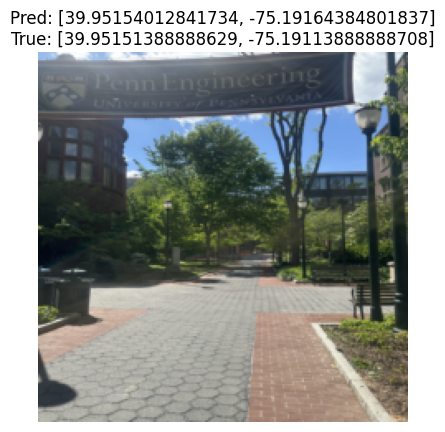

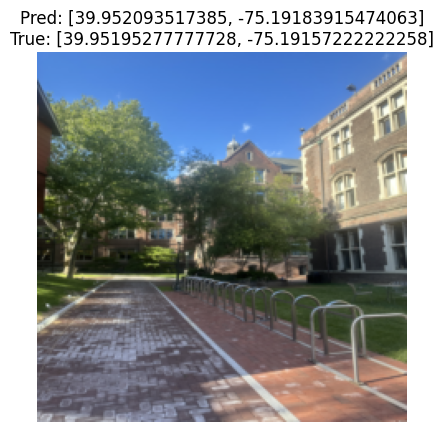

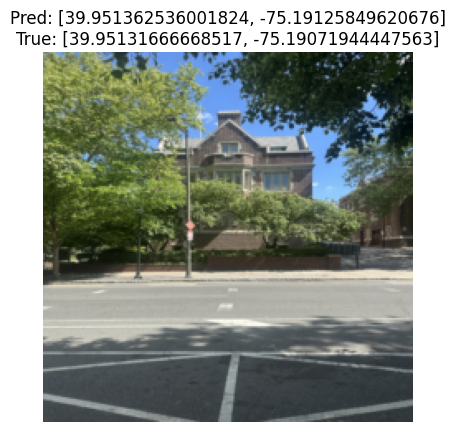

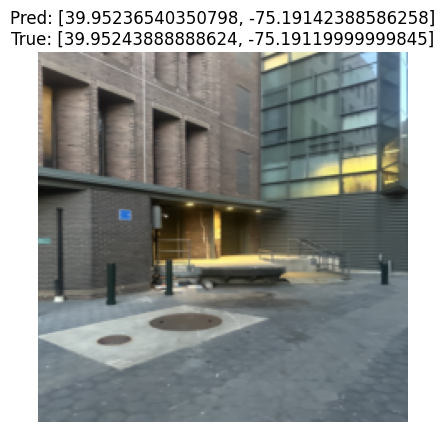

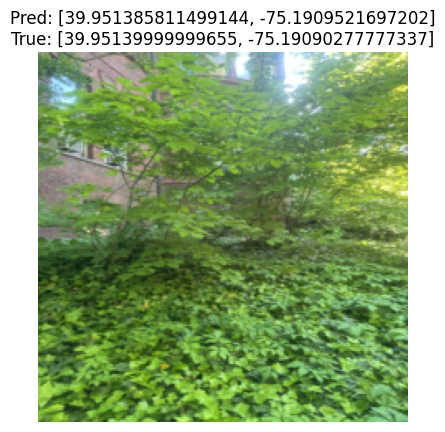

In [19]:
model = ResNet18LocationRegressor().to(device)

#Load the healthy weights from the disk
state_dict = torch.load('model.pt', map_location='cpu')
model.load_state_dict(state_dict)
model.to(device)

print("Success: model has been reset to the best saved weights.")

model.eval()

num_examples = 5

images, gps_coords = next(iter(val_dataloader))

images = images[:num_examples].to(device)
gps_coords = gps_coords[:num_examples]

with torch.no_grad():
    preds_norm = model(images).cpu()

stats_mean = torch.tensor([lat_mean, lon_mean])
stats_std = torch.tensor([lat_std, lon_std])

preds_real = preds_norm * stats_std + stats_mean
gps_real = gps_coords * stats_std + stats_mean

for i in range(num_examples):
    img = images[i].cpu()
    img = denormalize(img, mean=[0.485, 0.456, 0.406],
                      std=[0.229, 0.224, 0.225])

    plt.imshow(img)
    plt.title(f"Pred: {preds_real[i].tolist()}\nTrue: {gps_real[i].tolist()}")
    plt.axis("off")
    plt.show()

## Save model.pt

In [20]:
from pathlib import Path

model_path = Path("model.pt")
print("model.pt path:", model_path.resolve())
print("model.pt exists:", model_path.exists())


model.pt path: /content/model.pt
model.pt exists: True


In [21]:
# Optional Colab-only copy to Google Drive.
from google.colab import drive
drive.mount('/content/drive')
!cp model.pt /content/drive/MyDrive/model.pt


Mounted at /content/drive


In [ ]:
import torch
try:
    # Load with map_location="cpu" to ensure it works regardless of GPU availability
    state_dict = torch.load('model.pt', map_location='cpu')
    print("Success: model.pt loaded.")

    # Print the first few keys to make sure they look like layer names
    print("Sample keys:", list(state_dict.keys())[:5])
except Exception as e:
    print(f"Error: Could not load model.pt. Details: {e}")